## 10대는 0, 20대는 1, ..., 70대는 6 -> 총 7 클래스

columns = ['user_id', 'path', 'gender', 'age', 'age_class']로 통일

root는 age_root로 통일. path에는 028_data/data/~~~ 이런식으로 들어가야함

### 028_label

meta data에는 1071개 있는데, 실제 이미지는 965개가 존재한다. 이미지에 대해 join

In [ ]:
# meta data 가져오기
import pandas as pd
label_path = "/home/work/hocheol_dir/v0.2_data/_origin_data/028_data/메타데이터/meta_data.csv"
label_df = pd.read_csv(label_path)
label_df['subject_no'] = label_df['subject_no'].apply(lambda x:str(x).zfill(4))
label_df.head()

,subject_no,성별,나이,얼굴피부타입,자가민감여부,측정날짜
0,0001,여성,55,복합건성,아니오,2023-07-27
1,0002,여성,50,중성,아니오,2023-07-27
2,0003,여성,24,중성,아니오,2023-07-27
3,0004,여성,47,복합지성,예,2023-07-27
4,0006,여성,55,복합건성,아니오,2023-07-27


In [ ]:
# image path 가져오기
import os

age_root = '/home/work/hocheol_dir/v0.2_data/age'
image_df = pd.DataFrame(columns=['user_id', 'path'])

for image in os.listdir(os.path.join(age_root, '028_data/data')):
    user_id = image.split('_')[0]
    equipment = image.split('_')[1]
    image_df.loc[len(image_df)] = (user_id, os.path.join('028_data/data', image))
image_df.sort_values(by=['user_id', 'path'], inplace=True, ignore_index=True)

In [78]:
label_df.head()

,subject_no,성별,나이,얼굴피부타입,자가민감여부,측정날짜
0,0001,여성,55,복합건성,아니오,2023-07-27
1,0002,여성,50,중성,아니오,2023-07-27
2,0003,여성,24,중성,아니오,2023-07-27
3,0004,여성,47,복합지성,예,2023-07-27
4,0006,여성,55,복합건성,아니오,2023-07-27


In [90]:
merged_028 = pd.merge(image_df, label_df, how='inner', left_on='user_id', right_on='subject_no').drop(columns=['subject_no', '얼굴피부타입', '자가민감여부', '측정날짜'])
merged_028.rename(columns={'성별': 'gender', '나이': 'age'}, inplace=True)
merged_028['gender'] = merged_028['gender'].apply(lambda x: 'male' if x == '남성' else 'female')
merged_028 = merged_028[(merged_028['age'] >= 10) & (merged_028['age'] < 80)]

merged_028['age_class'] = merged_028['age'] // 10 - 1
merged_028

,user_id,path,gender,age,age_class
0,0001,028_data/data/0001_01_F.jpg,female,55,4
1,0001,028_data/data/0001_02_F.jpg,female,55,4
2,0001,028_data/data/0001_03_F.jpg,female,55,4
3,0002,028_data/data/0002_01_F.jpg,female,50,4
4,0002,028_data/data/0002_02_F.jpg,female,50,4
...,...,...,...,...,...
2890,1099,028_data/data/1099_02_F.jpg,female,26,1
2891,1099,028_data/data/1099_03_F.jpg,female,26,1
2892,1100,028_data/data/1100_01_F.jpg,female,28,1
2893,1100,028_data/data/1100_02_F.jpg,female,28,1


In [103]:
import json

with open(os.path.join(age_root, '028_data', 'label', 'age_label.json'), 'w') as f:
    json.dump(merged_028.to_dict(orient='records'), f, indent=2, ensure_ascii=False)

### 030_label

In [126]:
# meta data 가져오기
import pandas as pd
label_path = '/home/work/hocheol_dir/v0.2_data/_origin_data/030_data/meta_data_korean_wholebody.csv'
label_df = pd.read_csv(label_path)

label_df['user_id'] = label_df['filename'].apply(lambda x:x.split('_')[0])
print(len(label_df) == len(label_df['filename'].unique()))
label_df['filename'] = label_df['user_id']
label_df.drop(columns=['user_id'], inplace=True)
label_df.rename(columns={'filename': 'user_id'}, inplace=True)

label_df.rename(columns={'성별': 'gender', '나이': 'age'}, inplace=True)
label_df['gender'] = label_df['gender'].apply(lambda x: 'male' if x == '남자' else 'female')

label_df = label_df[(label_df['age'] >= 10) & (label_df['age'] < 80)]
label_df.head()

True


,user_id,gender,age
2,0003,male,16
3,0004,male,17
4,0005,male,17
5,0006,male,15
6,0007,male,18


In [127]:
# image path 가져오기
import os

age_root = '/home/work/hocheol_dir/v0.2_data/age'
image_df = pd.DataFrame(columns=['user_id', 'path'])

for image in os.listdir(os.path.join(age_root, '030_data/data')):
    user_id = image.split('_')[0]
    equipment = image.split('_')[1]
    image_df.loc[len(image_df)] = (user_id, os.path.join('030_data/data', image))
image_df.sort_values(by=['user_id', 'path'], inplace=True, ignore_index=True)
image_df.head()

,user_id,path
0,0001,030_data/data/0001_face.jpg
1,0002,030_data/data/0002_face.jpg
2,0003,030_data/data/0003_face.jpg
3,0004,030_data/data/0004_face.jpg
4,0005,030_data/data/0005_face.jpg


In [ ]:
merged_030 = pd.merge(image_df, label_df, how='inner', on='user_id')
merged_030['age_class'] = merged_030['age'] // 10 - 1
len(merged_030), len(image_df), len(label_df)

(1598, 1624, 1598)

In [135]:
json_path = os.path.join(age_root, '030_data', 'label', 'age_label.json')
os.makedirs(os.path.dirname(json_path), exist_ok=True)
with open(json_path, 'w') as f:
    json.dump(merged_030.to_dict(orient='records'), f, indent=2, ensure_ascii=False)

### 034_data

In [294]:
# meta data 가져오기
import pandas as pd
import os
import json
label_root = '/home/work/hocheol_dir/v0.2_data/_origin_data/034_selected_data/label'
labels = []

label_df = pd.DataFrame(columns=['user_id', 'gender', 'age'])

for root, dirs, files in os.walk(label_root):
    for file in files:
        if file.endswith('.json'):
            path = os.path.join(root, file)
            with open(path, 'r') as f:
                user_id = os.path.dirname(path).split('/')[-1]
                if user_id not in label_df['user_id'].values:
                    json_data = json.load(f)
                    label_df.loc[len(label_df)] = [user_id, json_data['gender'], json_data['age']]

label_df.sort_values(by=['user_id'], inplace=True, ignore_index=True)
len(label_df)

2700

In [295]:
label_df.head()

,user_id,gender,age
0,0000,M,28
1,0001,M,28
2,0002,M,34
3,0003,M,36
4,0004,M,41


In [296]:
# image path 가져오기
import os

age_root = '/home/work/hocheol_dir/v0.2_data/age'
image_df = pd.DataFrame(columns=['user_id', 'path'])

for image in os.listdir(os.path.join(age_root, '034_data/data')):
    user_id = image.split('_')[0]
    equipment = image.split('_')[1]
    image_df.loc[len(image_df)] = (user_id, os.path.join('034_data/data', image))
image_df.sort_values(by=['user_id', 'path'], inplace=True, ignore_index=True)
image_df.head()

,user_id,path
0,0000,034_data/data/0000_CRS_19_01.jpg
1,0000,034_data/data/0000_CRS_46_01.jpg
2,0001,034_data/data/0001_CRS_19_01.jpg
3,0001,034_data/data/0001_CRS_46_01.jpg
4,0002,034_data/data/0002_CRS_19_01.jpg


In [297]:
merged_034 = pd.merge(image_df, label_df, how='inner', on='user_id')
merged_034 = merged_034[(merged_034['age'] >= 10) & (merged_034['age'] < 80)]
merged_034['age_class'] = merged_034['age'] // 10 - 1
merged_034 = merged_034.dropna()
len(merged_034), len(image_df), len(label_df)

(5372, 5400, 2700)

In [298]:
merged_034['gender'] = merged_034['gender'].apply(lambda x:'male' if x == 'M' else 'female')

In [299]:
json_path = os.path.join(age_root, '034_data', 'label', 'age_label.json')
os.makedirs(os.path.dirname(json_path), exist_ok=True)
with open(json_path, 'w') as f:
    json.dump(merged_034.to_dict(orient='records'), f, indent=2, ensure_ascii=False)

### 045_data

In [25]:
# meta data(age)가 이미지 이름에 포함됨

In [300]:
# image path 가져오기
import os

age_root = '/home/work/hocheol_dir/v0.2_data/age'

exts = set()

for root, dirs, files in os.walk(os.path.join(age_root, '045_data/data')):
    for file in files:
        exts.add(file.split('.')[-1])
print(exts)

{'JPG', 'jpg'}


In [305]:
import re

image_df = pd.DataFrame(columns=['user_id', 'path'])

for root, dirs, files in os.walk(os.path.join(age_root, '045_data/data')):
    for file in files:
        if file.lower().endswith('.jpg') and '_0_' in file:
            user_id = re.search(r'F[0-9]{4}_[A-Z]+_[A-Z]+[0-9]*', file).group(0)
            age = file.split('_')[-3]
            if root.split('/')[-1] == 'iso400over':
                image_df.loc[len(image_df)] = (user_id, os.path.join('045_data/data/iso400over', file))
            else:    
                image_df.loc[len(image_df)] = (user_id, os.path.join('045_data/data', file))

image_df.sort_values(by=['user_id', 'path'], inplace=True, ignore_index=True)
image_df.head()

,user_id,path
0,F0001_IND_D,045_data/data/F0001_IND_D_18_0_01.JPG
1,F0001_IND_D,045_data/data/F0001_IND_D_18_0_02.JPG
2,F0001_IND_D,045_data/data/F0001_IND_D_18_0_03.JPG
3,F0001_IND_D,045_data/data/F0001_IND_D_18_0_04.JPG
4,F0001_IND_D,045_data/data/F0001_IND_D_18_0_05.JPG


In [308]:
image_df['gender'] = image_df['user_id'].apply(lambda x:x.split('_')[-1])
image_df['gender'].unique()

def relation_to_gender(relation):
    '''
    D 딸
    GM 할매
    M 엄마

    S 아덜
    F 아빠
    GF 할배
    '''

    female = ['D', 'GM', 'M']
    male = ['S', 'F', 'GF']

    sex = None
    for f in female:
        if relation.startswith(f):
            sex = 'female'
    for m in male:
        if relation.startswith(m):
            sex = 'male'
    
    if not sex:
        raise ValueError("Unknown Sex")
    
    return sex

image_df['gender'] = image_df['gender'].apply(lambda x: relation_to_gender(x))

image_df['age'] = image_df['path'].apply(lambda x: int(x.split('_')[-3]))
image_df['age_class'] = image_df['age'] // 10 - 1
image_df = image_df[(image_df['age'] >= 10) & (image_df['age'] < 80)]
image_df

,user_id,path,gender,age,age_class
0,F0001_IND_D,045_data/data/F0001_IND_D_18_0_01.JPG,female,18,0
1,F0001_IND_D,045_data/data/F0001_IND_D_18_0_02.JPG,female,18,0
2,F0001_IND_D,045_data/data/F0001_IND_D_18_0_03.JPG,female,18,0
3,F0001_IND_D,045_data/data/F0001_IND_D_18_0_04.JPG,female,18,0
4,F0001_IND_D,045_data/data/F0001_IND_D_18_0_05.JPG,female,18,0
...,...,...,...,...,...
3378,F0900_IND_D,045_data/data/F0900_IND_D_34_0_02.JPG,female,34,2
3379,F0900_IND_F,045_data/data/F0900_IND_F_59_0_01.JPG,male,59,4
3380,F0900_IND_F,045_data/data/F0900_IND_F_59_0_02.JPG,male,59,4
3381,F0900_IND_M,045_data/data/F0900_IND_M_57_0_01.JPG,female,57,4


In [309]:
image_df['new_path'] = image_df['path'].apply(lambda x: x.replace('/iso400over', ''))
image_df

,user_id,path,gender,age,age_class,new_path
0,F0001_IND_D,045_data/data/F0001_IND_D_18_0_01.JPG,female,18,0,045_data/data/F0001_IND_D_18_0_01.JPG
1,F0001_IND_D,045_data/data/F0001_IND_D_18_0_02.JPG,female,18,0,045_data/data/F0001_IND_D_18_0_02.JPG
2,F0001_IND_D,045_data/data/F0001_IND_D_18_0_03.JPG,female,18,0,045_data/data/F0001_IND_D_18_0_03.JPG
3,F0001_IND_D,045_data/data/F0001_IND_D_18_0_04.JPG,female,18,0,045_data/data/F0001_IND_D_18_0_04.JPG
4,F0001_IND_D,045_data/data/F0001_IND_D_18_0_05.JPG,female,18,0,045_data/data/F0001_IND_D_18_0_05.JPG
...,...,...,...,...,...,...
3378,F0900_IND_D,045_data/data/F0900_IND_D_34_0_02.JPG,female,34,2,045_data/data/F0900_IND_D_34_0_02.JPG
3379,F0900_IND_F,045_data/data/F0900_IND_F_59_0_01.JPG,male,59,4,045_data/data/F0900_IND_F_59_0_01.JPG
3380,F0900_IND_F,045_data/data/F0900_IND_F_59_0_02.JPG,male,59,4,045_data/data/F0900_IND_F_59_0_02.JPG
3381,F0900_IND_M,045_data/data/F0900_IND_M_57_0_01.JPG,female,57,4,045_data/data/F0900_IND_M_57_0_01.JPG


In [310]:
json_path = os.path.join(age_root, '045_data', 'label', 'age_label.json')
os.makedirs(os.path.dirname(json_path), exist_ok=True)
with open(json_path, 'w') as f:
    json.dump(image_df.to_dict(orient='records'), f, indent=2, ensure_ascii=False)

### 092_data

In [ ]:
# meta data(age)가 이미지 이름에 포함됨

In [93]:
# image path 가져오기
import os

age_root = '/home/work/hocheol_dir/v0.2_data/age'

exts = set()

for root, dirs, files in os.walk(os.path.join(age_root, '092_data/data')):
    for file in files:
        exts.add(file.split('.')[-1])
print(exts)

{'jpeg', 'jpg'}


In [95]:
import re

image_df = pd.DataFrame(columns=['user_id', 'path', 'gender', 'age'])

for root, dirs, files in os.walk(os.path.join(age_root, '092_data/data')):
    for file in files:
        if file.endswith('.jpg') or file.endswith('.jpeg'):
            user_id = file.split('_')[0]
            age = file.split('_')[2]
            gender = file.split('_')[1]
            image_df.loc[len(image_df)] = (user_id, os.path.join('092_data/data', file), gender, int(age))

image_df.sort_values(by=['user_id', 'path'], inplace=True, ignore_index=True)
image_df.head()

,user_id,path,gender,age
0,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,092_data/data/006b56dc2f8cda2361e1b01b2496d6f3...,여,20
1,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,092_data/data/006b56dc2f8cda2361e1b01b2496d6f3...,여,20
2,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,092_data/data/006b56dc2f8cda2361e1b01b2496d6f3...,여,20
3,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,092_data/data/006b56dc2f8cda2361e1b01b2496d6f3...,여,20
4,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,092_data/data/006b56dc2f8cda2361e1b01b2496d6f3...,여,20


In [96]:
image_df['gender'] = image_df['gender'].apply(lambda x:'male' if x == '남' else 'female')

image_df['age_class'] = image_df['age'] // 10 - 1
image_df = image_df[(image_df['age'] >= 10) & (image_df['age'] < 80)]
image_df

,user_id,path,gender,age,age_class
0,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,092_data/data/006b56dc2f8cda2361e1b01b2496d6f3...,female,20,1
1,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,092_data/data/006b56dc2f8cda2361e1b01b2496d6f3...,female,20,1
2,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,092_data/data/006b56dc2f8cda2361e1b01b2496d6f3...,female,20,1
3,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,092_data/data/006b56dc2f8cda2361e1b01b2496d6f3...,female,20,1
4,006b56dc2f8cda2361e1b01b2496d6f352dd5b1790f0a9...,092_data/data/006b56dc2f8cda2361e1b01b2496d6f3...,female,20,1
...,...,...,...,...,...
66567,fff3bc45e564d557af38b876dc5bdbe6185806c2573da2...,092_data/data/fff3bc45e564d557af38b876dc5bdbe6...,female,20,1
66568,fff3bc45e564d557af38b876dc5bdbe6185806c2573da2...,092_data/data/fff3bc45e564d557af38b876dc5bdbe6...,female,20,1
66569,fff3bc45e564d557af38b876dc5bdbe6185806c2573da2...,092_data/data/fff3bc45e564d557af38b876dc5bdbe6...,female,20,1
66570,fff3bc45e564d557af38b876dc5bdbe6185806c2573da2...,092_data/data/fff3bc45e564d557af38b876dc5bdbe6...,female,20,1


In [97]:
json_path = os.path.join(age_root, '092_data', 'label', 'age_label.json')
os.makedirs(os.path.dirname(json_path), exist_ok=True)
with open(json_path, 'w') as f:
    json.dump(image_df.to_dict(orient='records'), f, indent=2, ensure_ascii=False)

### 117_data

In [315]:
# meta data 가져오기
import pandas as pd
import os
import json


label_df = pd.read_csv('/home/work/hocheol_dir/v0.2_data/_origin_data/117_data/meta_face_parsing.csv')

label_df['id'] = label_df['id'].apply(lambda x:str(x).zfill(4))
label_df.rename(columns={'id':'user_id'}, inplace=True)

len(label_df)

16761

In [316]:
label_df.drop(columns=['device', 'location', 'accessory', 'box_w', 'box_h', 'pitch', 'yaw'], inplace=True)

In [317]:
label_df.head()

,filename,user_id,gender,age
0,0031_direct_indoor_normal_00000009.png,0031,female,27
1,0031_direct_indoor_normal_00000011.png,0031,female,27
2,0031_direct_outdoor_back_normal_00000020.png,0031,female,27
3,0031_direct_outdoor_direct_normal_00000023.png,0031,female,27
4,0031_wild_indoor_normal_00000040.png,0031,female,27


In [319]:
# image path 가져오기
import os

age_root = '/home/work/hocheol_dir/v0.2_data/age'
image_df = pd.DataFrame(columns=['user_id', 'path'])

for image in os.listdir(os.path.join(age_root, '117_data/data')):
    user_id = image.split('_')[0]
    equipment = image.split('_')[1]
    image_df.loc[len(image_df)] = (user_id, os.path.join('117_data/data', image))
image_df.sort_values(by=['user_id', 'path'], inplace=True, ignore_index=True)
image_df.head()

,user_id,path
0,0031,117_data/data/0031_direct_indoor_normal_000000...
1,0031,117_data/data/0031_direct_indoor_normal_000000...
2,0031,117_data/data/0031_direct_outdoor_back_normal_...
3,0031,117_data/data/0031_direct_outdoor_direct_norma...
4,0031,117_data/data/0031_wild_indoor_normal_00000040...


In [320]:
image_df['filename'] = image_df['path'].apply(lambda x: os.path.basename(x))
image_df.head()

,user_id,path,filename
0,0031,117_data/data/0031_direct_indoor_normal_000000...,0031_direct_indoor_normal_00000009.png
1,0031,117_data/data/0031_direct_indoor_normal_000000...,0031_direct_indoor_normal_00000011.png
2,0031,117_data/data/0031_direct_outdoor_back_normal_...,0031_direct_outdoor_back_normal_00000020.png
3,0031,117_data/data/0031_direct_outdoor_direct_norma...,0031_direct_outdoor_direct_normal_00000023.png
4,0031,117_data/data/0031_wild_indoor_normal_00000040...,0031_wild_indoor_normal_00000040.png


In [321]:
merged_117 = pd.merge(image_df, label_df, how='inner', on='filename')
merged_117 = merged_117[(merged_117['age'] >= 10) & (merged_117['age'] < 80)]
merged_117['age_class'] = merged_117['age'] // 10 - 1
merged_117 = merged_117.dropna()
len(merged_117), len(image_df), len(label_df)

(15784, 16757, 16761)

In [322]:
merged_117.drop(columns=['filename', 'user_id_y'], inplace=True)
merged_117.rename(columns={'user_id_x': 'user_id'}, inplace=True)
merged_117.head()

,user_id,path,gender,age,age_class
0,0031,117_data/data/0031_direct_indoor_normal_000000...,female,27,1
1,0031,117_data/data/0031_direct_indoor_normal_000000...,female,27,1
2,0031,117_data/data/0031_direct_outdoor_back_normal_...,female,27,1
3,0031,117_data/data/0031_direct_outdoor_direct_norma...,female,27,1
4,0031,117_data/data/0031_wild_indoor_normal_00000040...,female,27,1


In [323]:
json_path = os.path.join(age_root, '117_data', 'label', 'age_label.json')
os.makedirs(os.path.dirname(json_path), exist_ok=True)
with open(json_path, 'w') as f:
    json.dump(merged_117.to_dict(orient='records'), f, indent=2, ensure_ascii=False)

### 118_data

In [1]:
# meta data 가져오기
import pandas as pd
import os
import json

label_df = pd.read_csv('/home/work/hocheol_dir/v0.2_data/_origin_data/118_data/filtered_data.csv')

len(label_df)

2484

In [2]:
# image path 가져오기
import os

age_root = '/home/work/hocheol_dir/v0.2_data/age'
image_df = pd.DataFrame(columns=['user_id', 'path'])

for image in os.listdir(os.path.join(age_root, '118_data/data')):
    user_id = image.split('_')[0]
    equipment = image.split('_')[1]
    image_df.loc[len(image_df)] = (user_id, os.path.join('118_data/data', image))
image_df.sort_values(by=['user_id', 'path'], inplace=True, ignore_index=True)
image_df['age'] = image_df['path'].apply(lambda x: int(x.split('_')[-3]))
image_df['filename'] = image_df['path'].apply(lambda x: os.path.basename(x))
image_df

,user_id,path,age,filename
0,0001,118_data/data/0001_1992_28_00000071_D.png,28,0001_1992_28_00000071_D.png
1,0002,118_data/data/0002_1997_26_00000050_D.png,26,0002_1997_26_00000050_D.png
2,0002,118_data/data/0002_1997_26_00000051_D.png,26,0002_1997_26_00000051_D.png
3,0003,118_data/data/0003_1988_20_00000038_D.png,20,0003_1988_20_00000038_D.png
4,0003,118_data/data/0003_1988_20_00000046_D.png,20,0003_1988_20_00000046_D.png
...,...,...,...,...
2460,1003,118_data/data/1003_1997_22_00000018_D.png,22,1003_1997_22_00000018_D.png
2461,1003,118_data/data/1003_1997_23_00000021_D.png,23,1003_1997_23_00000021_D.png
2462,1004,118_data/data/1004_1999_21_00000030_d.png,21,1004_1999_21_00000030_d.png
2463,1004,118_data/data/1004_1999_24_00000043_d.png,24,1004_1999_24_00000043_d.png


In [11]:
merged_118 = pd.merge(label_df, image_df, how='inner', on='filename')

merged_118.drop(columns=['user_id_x', 'age_x'], inplace=True)
merged_118.rename(columns={'user_id_y': 'user_id', 'age_y': 'age'}, inplace=True)
merged_118 = merged_118[['user_id', 'path', 'gender', 'age']]

merged_118['age_class'] = merged_118['age'] // 10 - 1
merged_118 = merged_118.dropna()
len(merged_118), len(image_df), len(label_df)

(2465, 2465, 2484)

In [12]:
merged_118

,user_id,path,gender,age,age_class
0,0001,118_data/data/0001_1992_28_00000071_D.png,male,28,1
1,0002,118_data/data/0002_1997_26_00000050_D.png,female,26,1
2,0002,118_data/data/0002_1997_26_00000051_D.png,female,26,1
3,0003,118_data/data/0003_1988_20_00000038_D.png,male,20,1
4,0003,118_data/data/0003_1988_20_00000046_D.png,male,20,1
...,...,...,...,...,...
2460,1003,118_data/data/1003_1997_22_00000018_D.png,male,22,1
2461,1003,118_data/data/1003_1997_23_00000021_D.png,male,23,1
2462,1004,118_data/data/1004_1999_21_00000030_d.png,female,21,1
2463,1004,118_data/data/1004_1999_24_00000043_d.png,female,24,1


In [13]:
json_path = os.path.join(age_root, '118_data', 'label', 'age_label.json')
os.makedirs(os.path.dirname(json_path), exist_ok=True)
with open(json_path, 'w') as f:
    json.dump(merged_118.to_dict(orient='records'), f, indent=2, ensure_ascii=False)

### 282_data

In [1]:
import os
import json
import pandas as pd

root_dir = '/home/work/hocheol_dir/datasets/v0.2_data/_origin_data/282_data/labels'
json_paths = []
for TL in os.listdir(root_dir):
    root = os.path.join(root_dir, TL)
    if os.path.isdir(root):
        json_paths.extend([os.path.join(root, file) for file in os.listdir(root)])
        print(len(os.listdir(root)))

157048
132056
147295
155872
140830
135280
144266


In [18]:
label_df = pd.read_csv('/home/work/hocheol_dir/workspace/datasets/v0.2_data/_origin_data/282_data/filtered_metadata_final.csv')
label_df.head()

,filename,ID,inst,gender,age,glasses,yaw,pitch,roll,box_w,box_h
0,20220726_ID0001_C_01_N00070.png,ID0001,studio_camera_sony,female,20s,off,0,0,0,403,555
1,20220726_ID0001_C_01_N00116.png,ID0001,studio_camera_sony,female,20s,off,0,-10,0,417,580
2,20220726_ID0001_C_01_N00118.png,ID0001,studio_camera_sony,female,20s,off,0,-10,0,393,544
3,20220726_ID0001_C_01_N00119.png,ID0001,studio_camera_sony,female,20s,off,0,-10,0,401,557
4,20220726_ID0001_C_01_N00162.png,ID0001,studio_camera_sony,female,20s,off,0,0,0,406,540


In [37]:
label_df['age'].value_counts()

age
20s    23928
30s    23195
40s     5665
50s     4568
60s     2379
10s      886
70s      776
Name: count, dtype: int64

In [38]:
import os

label_df.rename(columns={'ID': 'user_id'}, inplace=True)
label_df = label_df[['user_id', 'filename', 'gender', 'age']]
# label_df['filename'] = label_df['filename'].apply(lambda x: os.path.splitext(x)[0])
label_df['age_class'] = label_df['age'].apply(lambda x:int(x.replace('s',''))//10-1)
label_df

,user_id,filename,gender,age,age_class
0,ID0001,20220726_ID0001_C_01_N00070.png,female,20s,1
1,ID0001,20220726_ID0001_C_01_N00116.png,female,20s,1
2,ID0001,20220726_ID0001_C_01_N00118.png,female,20s,1
3,ID0001,20220726_ID0001_C_01_N00119.png,female,20s,1
4,ID0001,20220726_ID0001_C_01_N00162.png,female,20s,1
...,...,...,...,...,...
61392,ID6002,20230130_ID6002_C_01_N00140.png,female,20s,1
61393,ID6002,20230130_ID6002_C_01_N00220.png,female,20s,1
61394,ID6002,20230130_ID6002_C_01_N00222.png,female,20s,1
61395,ID6002,20230130_ID6002_C_01_N00224.png,female,20s,1


In [39]:
# image path 가져오기
import os

age_root = '/home/work/hocheol_dir/datasets/v0.2_data/age'
image_df = pd.DataFrame(columns=['user_id', 'path'])

for image in os.listdir(os.path.join(age_root, '282_data/data')):
    user_id = image.split('_')[1]
    image_df.loc[len(image_df)] = (user_id, os.path.join('282_data/data', image))
image_df.sort_values(by=['user_id', 'path'], inplace=True, ignore_index=True)
image_df

,user_id,path
0,ID0001,282_data/data/20220726_ID0001_C_01_N00070.png
1,ID0001,282_data/data/20220726_ID0001_C_01_N00162.png
2,ID0001,282_data/data/20220726_ID0001_C_01_N00191.png
3,ID0001,282_data/data/20220726_ID0001_C_01_N00323.png
4,ID0001,282_data/data/20220726_ID0001_C_02_N00088.png
...,...,...
23916,ID6001,282_data/data/20230126_ID6001_C_03_N00156.png
23917,ID6001,282_data/data/20230126_ID6001_C_03_N00182.png
23918,ID6001,282_data/data/20230126_ID6001_C_03_N00198.png
23919,ID6001,282_data/data/20230126_ID6001_C_03_N00201.png


In [40]:
image_df['filename'] = image_df['path'].apply(lambda x:os.path.basename(x))
image_df

,user_id,path,filename
0,ID0001,282_data/data/20220726_ID0001_C_01_N00070.png,20220726_ID0001_C_01_N00070.png
1,ID0001,282_data/data/20220726_ID0001_C_01_N00162.png,20220726_ID0001_C_01_N00162.png
2,ID0001,282_data/data/20220726_ID0001_C_01_N00191.png,20220726_ID0001_C_01_N00191.png
3,ID0001,282_data/data/20220726_ID0001_C_01_N00323.png,20220726_ID0001_C_01_N00323.png
4,ID0001,282_data/data/20220726_ID0001_C_02_N00088.png,20220726_ID0001_C_02_N00088.png
...,...,...,...
23916,ID6001,282_data/data/20230126_ID6001_C_03_N00156.png,20230126_ID6001_C_03_N00156.png
23917,ID6001,282_data/data/20230126_ID6001_C_03_N00182.png,20230126_ID6001_C_03_N00182.png
23918,ID6001,282_data/data/20230126_ID6001_C_03_N00198.png,20230126_ID6001_C_03_N00198.png
23919,ID6001,282_data/data/20230126_ID6001_C_03_N00201.png,20230126_ID6001_C_03_N00201.png


In [41]:
label_df

,user_id,filename,gender,age,age_class
0,ID0001,20220726_ID0001_C_01_N00070.png,female,20s,1
1,ID0001,20220726_ID0001_C_01_N00116.png,female,20s,1
2,ID0001,20220726_ID0001_C_01_N00118.png,female,20s,1
3,ID0001,20220726_ID0001_C_01_N00119.png,female,20s,1
4,ID0001,20220726_ID0001_C_01_N00162.png,female,20s,1
...,...,...,...,...,...
61392,ID6002,20230130_ID6002_C_01_N00140.png,female,20s,1
61393,ID6002,20230130_ID6002_C_01_N00220.png,female,20s,1
61394,ID6002,20230130_ID6002_C_01_N00222.png,female,20s,1
61395,ID6002,20230130_ID6002_C_01_N00224.png,female,20s,1


In [44]:
merged_df = pd.merge(image_df, label_df.drop(columns=['user_id']), how='inner', on='filename')
len(merged_df), merged_df['age'].value_counts().sort_index()

(23921,
 age
 10s     311
 20s    8608
 30s    8623
 40s    2618
 50s    2124
 60s    1186
 70s     451
 Name: count, dtype: int64)

In [47]:
merged_df = merged_df[['user_id', 'path', 'gender', 'age', 'age_class']].sort_values(by=['user_id', 'path'], ignore_index=True)
merged_df

,user_id,path,gender,age,age_class
0,ID0001,282_data/data/20220726_ID0001_C_01_N00070.png,female,20s,1
1,ID0001,282_data/data/20220726_ID0001_C_01_N00162.png,female,20s,1
2,ID0001,282_data/data/20220726_ID0001_C_01_N00191.png,female,20s,1
3,ID0001,282_data/data/20220726_ID0001_C_01_N00323.png,female,20s,1
4,ID0001,282_data/data/20220726_ID0001_C_02_N00088.png,female,20s,1
...,...,...,...,...,...
23916,ID6001,282_data/data/20230126_ID6001_C_03_N00156.png,female,20s,1
23917,ID6001,282_data/data/20230126_ID6001_C_03_N00182.png,female,20s,1
23918,ID6001,282_data/data/20230126_ID6001_C_03_N00198.png,female,20s,1
23919,ID6001,282_data/data/20230126_ID6001_C_03_N00201.png,female,20s,1


In [48]:
json_path = os.path.join(age_root, '282_data', 'label', 'age_label.json')
os.makedirs(os.path.dirname(json_path), exist_ok=True)
with open(json_path, 'w') as f:
    json.dump(merged_df.to_dict(orient='records'), f, indent=2, ensure_ascii=False)

### 999_data

In [58]:
import os
import pandas as pd
import json


label_df = pd.read_csv('/home/work/hocheol_dir/v0.2_data/_origin_data/999_data/NIA_online_meta.csv')
label_df = pd.concat([label_df, pd.read_csv('/home/work/hocheol_dir/v0.2_data/_origin_data/999_data/NIA_SNUH_meta.csv')], ignore_index=True)
label_df

,subject_no,Age,gender,age
0,6101,30.0,female,NaN
1,6102,35.0,male,NaN
2,6103,20.0,female,NaN
3,6104,28.0,male,NaN
4,6105,30.0,female,NaN
...,...,...,...,...
297,36023,NaN,female,24.0
298,36024,NaN,female,27.0
299,36025,NaN,female,24.0
300,36026,NaN,female,21.0


In [59]:
label_df['age'] = label_df['Age'].combine_first(label_df['age'])
label_df.drop(columns=['Age'], inplace=True)
label_df

,subject_no,gender,age
0,6101,female,30.0
1,6102,male,35.0
2,6103,female,20.0
3,6104,male,28.0
4,6105,female,30.0
...,...,...,...
297,36023,female,24.0
298,36024,female,27.0
299,36025,female,24.0
300,36026,female,21.0


In [60]:
label_df['age'] = label_df['age'].apply(lambda x:int(x))
label_df

,subject_no,gender,age
0,6101,female,30
1,6102,male,35
2,6103,female,20
3,6104,male,28
4,6105,female,30
...,...,...,...
297,36023,female,24
298,36024,female,27
299,36025,female,24
300,36026,female,21


In [61]:
label_df

,subject_no,gender,age
0,6101,female,30
1,6102,male,35
2,6103,female,20
3,6104,male,28
4,6105,female,30
...,...,...,...
297,36023,female,24
298,36024,female,27
299,36025,female,24
300,36026,female,21


In [62]:
age_root = '/home/work/hocheol_dir/v0.2_data/age'
exts = set()

for root, dirs, files in os.walk(os.path.join(age_root, '999_data/data')):
    for file in files:
        exts.add(file.split('.')[-1])
print(exts)

{'jpg', 'JPG', 'png', 'jpeg'}


In [63]:
# image path 가져오기
import os

image_df = pd.DataFrame(columns=['user_id', 'path'])

for root, dirs, files in os.walk(os.path.join(age_root, '999_data/data')):
    for file in files:
        if file.endswith(('.jpg', '.jpeg', '.png', 'JPG')):
            user_id = file.split('_')[0]
            image_df.loc[len(image_df)] = (user_id, os.path.join('999_data/data', os.path.basename(root), file))

image_df.sort_values(by=['user_id', 'path'], inplace=True, ignore_index=True)
image_df

,user_id,path
0,31001,999_data/data/SNUH_final/31001_01_F.JPG
1,31001,999_data/data/SNUH_final/31001_01_F_2.JPG
2,31001,999_data/data/SNUH_final/31001_02_F.png
3,31001,999_data/data/SNUH_final/31001_03_F.png
4,31001,999_data/data/SNUH_final/31001_03_F_2.png
...,...,...
1989,6302,999_data/data/online/6302_5_F_2.jpg
1990,6302,999_data/data/online/6302_6_F.jpg
1991,6302,999_data/data/online/6302_6_F_2.jpg
1992,6302,999_data/data/online/6302_7_F.jpg


In [64]:
image_df['user_id'] = image_df['user_id'].astype(int)
image_df['user_id']

0       31001
1       31001
2       31001
3       31001
4       31001
        ...  
1989     6302
1990     6302
1991     6302
1992     6302
1993     6302
Name: user_id, Length: 1994, dtype: int64

In [65]:
merged_999 = pd.merge(label_df, image_df, how='right', left_on='subject_no', right_on='user_id')
merged_999 = merged_999[(merged_999['age'] >= 10) & (merged_999['age'] < 80)]
merged_999['age_class'] = merged_999['age'] // 10 - 1
len(merged_999), len(image_df), len(label_df)

(1990, 1994, 302)

In [66]:
merged_999['subject_no'] = merged_999['user_id']
merged_999['age_class'] = merged_999['age_class'].astype(int)
merged_999.drop(columns=['user_id'], inplace=True)
merged_999.rename(columns={'subject_no': 'user_id'}, inplace=True)
merged_999

,user_id,gender,age,path,age_class
0,31001,male,23,999_data/data/SNUH_final/31001_01_F.JPG,1
1,31001,male,23,999_data/data/SNUH_final/31001_01_F_2.JPG,1
2,31001,male,23,999_data/data/SNUH_final/31001_02_F.png,1
3,31001,male,23,999_data/data/SNUH_final/31001_03_F.png,1
4,31001,male,23,999_data/data/SNUH_final/31001_03_F_2.png,1
...,...,...,...,...,...
1989,6302,male,23,999_data/data/online/6302_5_F_2.jpg,1
1990,6302,male,23,999_data/data/online/6302_6_F.jpg,1
1991,6302,male,23,999_data/data/online/6302_6_F_2.jpg,1
1992,6302,male,23,999_data/data/online/6302_7_F.jpg,1


In [68]:
json_path = os.path.join(age_root, '999_data', 'label', 'age_label.json')
os.makedirs(os.path.dirname(json_path), exist_ok=True)
with open(json_path, 'w') as f:
    json.dump(merged_999.to_dict(orient='records'), f, indent=2, ensure_ascii=False)

### 114_data

In [2]:
import os
import pandas as pd
import json


label_df = pd.read_csv('/home/work/hocheol_dir/workspace/datasets/v0.2_data/_origin_data/114_data/filtered_meta_info_age_adjusted.csv')
label_df['Id'] = label_df['Id'].apply(lambda x: str(x).zfill(4))
label_df = label_df[label_df['Age'] != 0]
label_df.columns = [x.lower() for x in label_df.columns]
label_df.rename(columns={'id': 'user_id', 'sex': 'gender'}, inplace=True)
label_df = label_df[['user_id', 'gender', 'age']]
label_df['gender'] = label_df['gender'].apply(lambda x: 'male' if x == 'M' else 'female')
label_df['age_class'] = label_df['age'] // 10 - 1
label_df['age'] = label_df['age'].apply(lambda x: str(x)+'s')
label_df

,user_id,gender,age,age_class
0,0166,male,20s,1
1,0171,female,50s,4
2,0175,female,20s,1
3,0179,male,20s,1
4,0183,female,10s,0
...,...,...,...,...
1275,2976,female,10s,0
1277,2978,female,40s,3
1278,2989,male,30s,2
1279,2994,male,10s,0


In [3]:
# label_df['age'] = label_df['age'].apply(lambda x:int(x))
# label_df

In [4]:
label_df

,user_id,gender,age,age_class
0,0166,male,20s,1
1,0171,female,50s,4
2,0175,female,20s,1
3,0179,male,20s,1
4,0183,female,10s,0
...,...,...,...,...
1275,2976,female,10s,0
1277,2978,female,40s,3
1278,2989,male,30s,2
1279,2994,male,10s,0


In [5]:
age_root = '/home/work/hocheol_dir/datasets/v0.2_data/age'
exts = set()

for root, dirs, files in os.walk(os.path.join(age_root, '114_data/data')):
    for file in files:
        exts.add(file.split('.')[-1])
print(exts)

{'jpg'}


In [6]:
# image path 가져오기
import os

image_df = pd.DataFrame(columns=['user_id', 'path'])

for root, dirs, files in os.walk(os.path.join(age_root, '114_data/data')):
    for file in files:
        user_id = file.split('_')[0]
        image_df.loc[len(image_df)] = (user_id, os.path.join('114_data/data', file))

image_df.sort_values(by=['user_id', 'path'], inplace=True, ignore_index=True)
image_df

,user_id,path
0,0166,114_data/data/0166_Phone_High_001.jpg
1,0166,114_data/data/0166_Phone_High_002.jpg
2,0166,114_data/data/0166_Phone_High_003.jpg
3,0166,114_data/data/0166_Phone_High_004.jpg
4,0166,114_data/data/0166_Phone_High_018.jpg
...,...,...
61032,2995,114_data/data/2995_Tablet_Mid_021.jpg
61033,2995,114_data/data/2995_Tablet_Mid_023.jpg
61034,2995,114_data/data/2995_Tablet_Mid_024.jpg
61035,2995,114_data/data/2995_Tablet_Mid_029.jpg


In [7]:
merged_df = pd.merge(label_df, image_df, how='inner', on='user_id')
len(merged_df), len(image_df), len(label_df)

(59562, 61037, 1247)

In [8]:
merged_df.isna().sum(), merged_df.isnull().sum()

(user_id      0
 gender       0
 age          0
 age_class    0
 path         0
 dtype: int64,
 user_id      0
 gender       0
 age          0
 age_class    0
 path         0
 dtype: int64)

In [9]:
merged_df = merged_df[['user_id', 'path', 'gender', 'age', 'age_class']]
merged_df

,user_id,path,gender,age,age_class
0,0166,114_data/data/0166_Phone_High_001.jpg,male,20s,1
1,0166,114_data/data/0166_Phone_High_002.jpg,male,20s,1
2,0166,114_data/data/0166_Phone_High_003.jpg,male,20s,1
3,0166,114_data/data/0166_Phone_High_004.jpg,male,20s,1
4,0166,114_data/data/0166_Phone_High_018.jpg,male,20s,1
...,...,...,...,...,...
59557,2995,114_data/data/2995_Tablet_Mid_021.jpg,male,10s,0
59558,2995,114_data/data/2995_Tablet_Mid_023.jpg,male,10s,0
59559,2995,114_data/data/2995_Tablet_Mid_024.jpg,male,10s,0
59560,2995,114_data/data/2995_Tablet_Mid_029.jpg,male,10s,0


In [10]:
json_path = os.path.join(age_root, '114_data', 'label', 'age_label.json')
os.makedirs(os.path.dirname(json_path), exist_ok=True)
with open(json_path, 'w') as f:
    json.dump(merged_df.to_dict(orient='records'), f, indent=2, ensure_ascii=False)

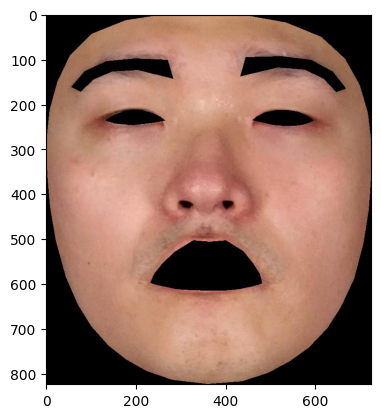

In [11]:
import cv2
import matplotlib.pyplot as plt

plt.imshow(cv2.cvtColor(cv2.imread(os.path.join(age_root, '114_data/data/0166_Phone_High_002.jpg')), cv2.COLOR_BGR2RGB))
plt.show()